---
## ✏️ Step 6: 도전 과제

아래 과제를 직접 코드로 구현해 보세요!

### 🟢 기초
1. 노이즈 확률(`noise_prob`)을 `0.1`, `0.2`로 높여보세요. 정확도가 어떻게 변하나요?
2. Hidden Layer 크기를 `64 → 32`로 바꿔보세요.

### 🟡 중급
3. Adam 대신 `SGD`(momentum=0.9) 옵티마이저를 사용해보세요.
4. 학습률(`lr`)을 `0.01`, `0.0001`로 바꿔 수렴 속도를 비교하세요.

### 🔴 심화
5. `nn.Dropout(0.3)`을 은닉층 사이에 추가해보세요. 효과가 있나요?
6. 새로운 "숫자"(예: 0~9 외의 특수 패턴)를 직접 정의하여 클래스를 추가해보세요.

In [2]:
# ✏️ 여기에 도전 과제 코드를 작성하세요!

# 예시: noise_prob 변경 실험
# X_noisy, y_noisy = augment_data(SEGMENTS, samples_per_class=200, noise_prob=0.15)
# ... (학습 코드 반복)

print('도전 과제를 직접 구현해보세요! 🚀')

# 환경설정 
import numpy as np
import torch  #
import torch.nn as nn # neural network 약자. 네트워크 층을 쌓거나 손실 함수(CrossEntropyLoss) 등을 모아둔 모듈
import torch.optim as optim # 최적화 알고리즘(Adam, SGD 등)을 모아둔 모듈
from torch.utils.data import TensorDataset, DataLoader # 데이터를 적절한 크기로 모델에 보내는 모듈
import matplotlib.pyplot as plt
import matplotlib.patches as patches # 그래프 위에 도형(네모, 원)을 그리는 모듈
import seaborn as sns
from sklearn.model_selection import train_test_split

# 재현성을 위한 시드 고정
np.random.seed(42)
torch.manual_seed(42)

print(f'\nPyTorch 버전: {torch.__version__}')
print(f'GPU 사용 가능: {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'학습 디바이스: {device}')

# 한글 폰트 설정(추가 입력)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ─── 7-Segment 이상적 패턴 정의 ───────────────────────────────────────────
#         [a, b, c, d, e, f, g]
SEGMENTS = {
    0: [1, 1, 1, 1, 1, 1, 0],
    1: [0, 1, 1, 0, 0, 0, 0],
    2: [1, 1, 0, 1, 1, 0, 1],
    3: [1, 1, 1, 1, 0, 0, 1],
    4: [0, 1, 1, 0, 0, 1, 1],
    5: [1, 0, 1, 1, 0, 1, 1],
    6: [1, 0, 1, 1, 1, 1, 1],
    7: [1, 1, 1, 0, 0, 0, 0],
    8: [1, 1, 1, 1, 1, 1, 1],
    9: [1, 1, 1, 1, 0, 1, 1],
}

도전 과제를 직접 구현해보세요! 🚀

PyTorch 버전: 2.6.0+cu124
GPU 사용 가능: True
학습 디바이스: cuda



----- 노이즈확률별 데이터 형태, 클래스 분포, 학습/테스트 데이터 수 -----
<노이즈확률 0.05>
생성된 데이터 형태: X_1=(2000, 7), y_1=(2000,)
클래스 분포: {np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200), np.int64(4): np.int64(200), np.int64(5): np.int64(200), np.int64(6): np.int64(200), np.int64(7): np.int64(200), np.int64(8): np.int64(200), np.int64(9): np.int64(200)}
학습 데이터: 1600개
테스트 데이터: 400개

<노이즈확률 0.1>
생성된 데이터 형태: X_2=(2000, 7), y_2=(2000,)
클래스 분포: {np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200), np.int64(4): np.int64(200), np.int64(5): np.int64(200), np.int64(6): np.int64(200), np.int64(7): np.int64(200), np.int64(8): np.int64(200), np.int64(9): np.int64(200)}
학습 데이터: 1600개
테스트 데이터: 400개

<노이즈확률 0.2>
생성된 데이터 형태: X_3=(2000, 7), y_3=(2000,)
클래스 분포: {np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200), np.int64(4): np.int64(200), np.int64(5):

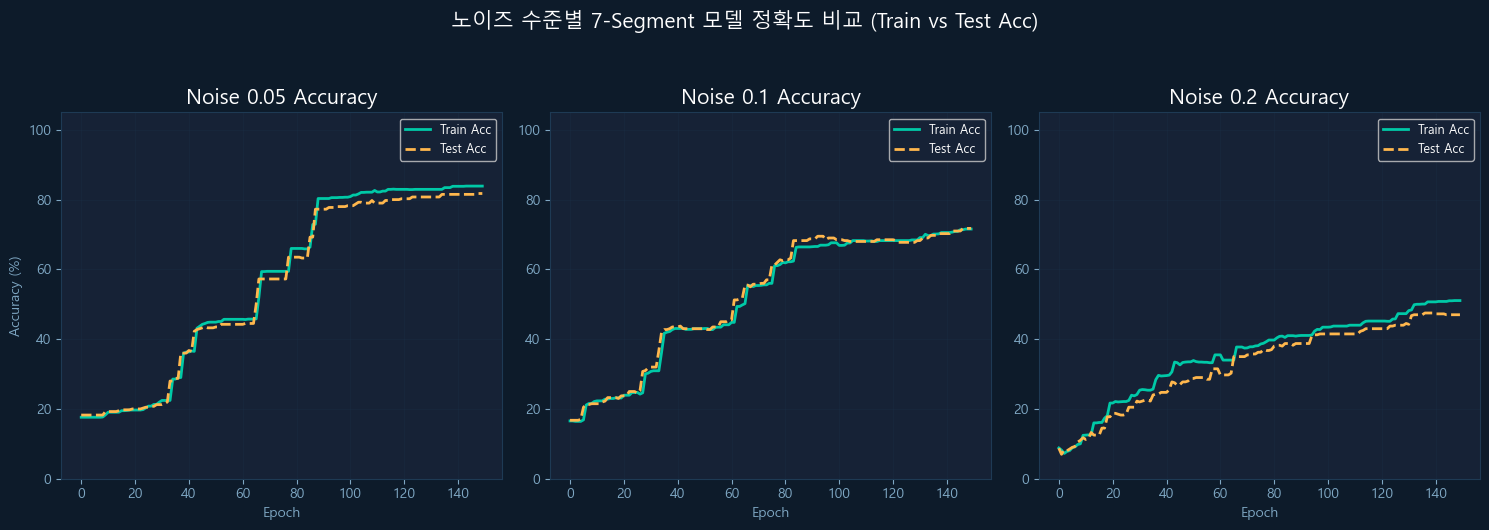

─── 각 노이즈별 최종 Test Accuracy 성적 ───
Noise Prob 0.05: 81.75%
Noise Prob 0.1: 71.75%
Noise Prob 0.2: 47.00%


In [45]:
# 1. 기초 : 노이즈 확률을 0.1, 0.2로 높여 정확도 확인 및 히든 레이어 크기를 64 -> 32 로 변환
# 1-1 노이즈 확률을 0.1, 0.2로 높여 정확도 확인
# 데이터 증강: 노이즈 추가 0.05, 01. 0.2
def augment_data(segments_dict, samples_per_class, noise_prob):
    """
    각 숫자 패턴에 랜덤 노이즈(비트 플립)를 추가하여 학습 데이터를 생성합니다.
    
    Args:
        samples_per_class: 각 클래스당 생성할 샘플 수
        noise_prob: 각 비트가 뒤집힐 확률
    """
    X_list, y_list = [], []
    for digit, pattern in segments_dict.items():
        for _ in range(samples_per_class):
            # 노이즈 생성: 각 비트를 noise_prob 확률로 플립
            noise = np.random.binomial(1, noise_prob, size=7) #binomial : 이항분포
            noisy = np.array(pattern) ^ noise  # XOR로 비트 플립
            X_list.append(noisy.astype(np.float32))
            y_list.append(digit)

    return np.array(X_list), np.array(y_list)

# X_1, y_1 데이터 만들기
X_1, y_1 = augment_data(SEGMENTS, samples_per_class=200, noise_prob=0.05)
# X_2, y_2 데이터 만들기
X_2, y_2 = augment_data(SEGMENTS, samples_per_class=200, noise_prob=0.1)
# X_3, y_3 데이터 만들기
X_3, y_3 = augment_data(SEGMENTS, samples_per_class=200, noise_prob=0.2)

# Train / Test 분할
# X_1, y_1
X_1_train, X_1_test, y_1_train, y_1_test = train_test_split(
    X_1, y_1, test_size=0.2, random_state=42, stratify=y_1  # stratify=y : 각 digit 데이터들이 같은 비율로 훈련셋과 테스트셋에 담기도록 함
)
# X_2, y_2
X_2_train, X_2_test, y_2_train, y_2_test = train_test_split(
    X_2, y_2, test_size=0.2, random_state=42, stratify=y_2 
)
# X_3, y_3
X_3_train, X_3_test, y_3_train, y_3_test = train_test_split(
    X_3, y_3, test_size=0.2, random_state=42, stratify=y_3  
)

print('\n----- 노이즈확률별 데이터 형태, 클래스 분포, 학습/테스트 데이터 수 -----')
print('<노이즈확률 0.05>')
print(f'생성된 데이터 형태: X_1={X_1.shape}, y_1={y_1.shape}')
print(f'클래스 분포: {dict(zip(*np.unique(y_1, return_counts=True)))}')
print(f'학습 데이터: {X_1_train.shape[0]}개')
print(f'테스트 데이터: {X_1_test.shape[0]}개')
print('\n<노이즈확률 0.1>')
print(f'생성된 데이터 형태: X_2={X_2.shape}, y_2={y_2.shape}')
print(f'클래스 분포: {dict(zip(*np.unique(y_2, return_counts=True)))}')
print(f'학습 데이터: {X_2_train.shape[0]}개')
print(f'테스트 데이터: {X_2_test.shape[0]}개')
print('\n<노이즈확률 0.2>')
print(f'생성된 데이터 형태: X_3={X_3.shape}, y_3={y_3.shape}')
print(f'클래스 분포: {dict(zip(*np.unique(y_3, return_counts=True)))}')
print(f'학습 데이터: {X_3_train.shape[0]}개')
print(f'테스트 데이터: {X_3_test.shape[0]}개')

# PyTorch 텐서로 변환
# X_1, y_1
X_1_train_t = torch.FloatTensor(X_1_train).to(device)
y_1_train_t = torch.LongTensor(y_1_train).to(device)
X_1_test_t  = torch.FloatTensor(X_1_test).to(device)
y_1_test_t  = torch.LongTensor(y_1_test).to(device)
# X_2, y_2
X_2_train_t = torch.FloatTensor(X_2_train).to(device)
y_2_train_t = torch.LongTensor(y_2_train).to(device)
X_2_test_t  = torch.FloatTensor(X_2_test).to(device)
y_2_test_t  = torch.LongTensor(y_2_test).to(device)
# X_3, y_3
X_3_train_t = torch.FloatTensor(X_3_train).to(device)
y_3_train_t = torch.LongTensor(y_3_train).to(device)
X_3_test_t  = torch.FloatTensor(X_3_test).to(device)
y_3_test_t  = torch.LongTensor(y_3_test).to(device)


# MLP 모델 정의
class SevenSegmentNet(nn.Module):
    """
    7-Segment 숫자 분류를 위한 MLP 모델
    
    Architecture:
        Input(7) → FC(32) → ReLU → FC(16) → ReLU → FC(10)
    """
    def __init__(self, input_size=7, hidden1=32, hidden2=16, num_classes=10):
        super(SevenSegmentNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),  # 입력층 → 은닉층 1
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),     # 은닉층 1 → 은닉층 2
            nn.ReLU(),
            nn.Linear(hidden2, num_classes), # 은닉층 2 → 출력층
        )
        # 가중치 초기화 (Xavier Uniform)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """순전파: CrossEntropyLoss가 내부적으로 Softmax를 포함하므로 raw logits 반환"""
        return self.network(x)


# 모델 생성 및 구조 출력
model = SevenSegmentNet().to(device)
print('\n모델정보 : ', model)
print(f'\n총 파라미터 수: {sum(p.numel() for p in model_info.parameters()):,}개')


# 하이퍼파라미터 
LEARNING_RATE = 0.001
NUM_EPOCHS    = 150

# 손실함수
criterion = nn.CrossEntropyLoss()  # 다중 클래스 분류 손실함수 (Softmax 포함)

# 학습 기록 저장
histories = [
    {'train_loss': [], 'train_acc': [], 'test_acc': []}, # history_1
    {'train_loss': [], 'train_acc': [], 'test_acc': []}, # history_2
    {'train_loss': [], 'train_acc': [], 'test_acc': []}  # history_3
]

# 학습할 데이터 묶음 만들기
data_groups = [
    (X_1_train_t, y_1_train_t, X_1_test_t, y_1_test_t, 0.05),
    (X_2_train_t, y_2_train_t, X_2_test_t, y_2_test_t, 0.1),
    (X_3_train_t, y_3_train_t, X_3_test_t, y_3_test_t, 0.2)
]

# ─── 학습 루프 ────────────────────────────────────────────────────────────
print(f'학습 시작 (Epochs: {NUM_EPOCHS}, lr: {LEARNING_RATE})')
print('-' * 50)

for i, (X_train, y_train, X_test, y_test, noise) in enumerate(data_groups):
    print(f'\n[데이터셋 {i+1}] 노이즈 확률: {noise} 학습 중...')
    model = SevenSegmentNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history = histories[i] # 현재 노이즈 수준에 맞는 히스토리 선택

    for epoch in range(NUM_EPOCHS):
       # ── 학습 모드 ──
        model.train()
        optimizer.zero_grad()          # 이전 그래디언트 초기화
        outputs = model(X_train)     # 순전파
        loss = criterion(outputs, y_train)  # 손실 계산
        loss.backward()                # 역전파
        optimizer.step()               # 가중치 업데이트

    # ── 학습 정확도 ──
     # torch.max 함수는 첫 번째: 가장 높게 나온 '점수와 두 번째: 그 점수가 있던 '자리 번호' 반환
     # _,라고 적어서 첫 번째 결과물(점수)은 안 받겠다는 뜻을 표시하고, 두 번째 결과물(자리 번호)만 받음
        _, predicted_train = torch.max(outputs, 1)

     # predicted_train == y_train_t로 [True, False, True, True]로 만들고, float으로 이를 숫자로 변환
     # 그 후 mean으로 정답지의 평균('정확도') 구하고, item으로 파이토치 안에 있는 숫자만 꺼냄
        train_acc = (predicted_train == y_train).float().mean().item()

    # ── 테스트 평가 및 정확도 ──
        model.eval()
        with torch.no_grad():   ## 이미 미분을 했기에 평가할 때는 no_grad로!! 매우 중요-대형 모델 성능영향
            test_outputs  = model(X_test)
            _, predicted_test = torch.max(test_outputs, 1)
            test_acc = (predicted_test == y_test).float().mean().item()

    # 기록 저장 // matplotlib 같은 시각화 도구를 써서 오차 그래프, 정확도 그래프를 그릴 재료 모으기
        history['train_loss'].append(loss.item())
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

    # 진행 상황 출력 (매 30 epoch)
        if (epoch + 1) % 30 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1:>3}/{NUM_EPOCHS}]  '  # :>3 출력시 앞 쪽에 3칸의 여백을 써주기
                  f'Loss: {loss.item():.4f}  '
                  f'Train Acc: {train_acc*100:.1f}%  '
                  f'Test Acc: {test_acc*100:.1f}%')

print('\n✅ 모든 노이즈 데이터 셋 학습 완료!')

# ─── 정확도 곡선 시각화 ────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#0d1b2a')

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor('#162236')
    ax.tick_params(colors='#7fa8c4')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e3a54')
    ax.set_xlabel('Epoch', color='#7fa8c4')
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.2, color='#1e3a54')

# [Ax 1] 노이즈 0.05 (history_1)
ax1.plot([a*100 for a in histories[0]['train_acc']], color='#00c9a7', linewidth=2, label='Train Acc')
ax1.plot([a*100 for a in histories[0]['test_acc']],  color='#ffb74d', linewidth=2, label='Test Acc', linestyle='--')
ax1.set_title('Noise 0.05 Accuracy', color='white', fontsize=15)
ax1.set_ylabel('Accuracy (%)', color='#7fa8c4')
ax1.legend(facecolor='#162236', labelcolor='white', fontsize=9)

# [Ax 2] 노이즈 0.1 (history_2)
ax2.plot([a*100 for a in histories[1]['train_acc']], color='#00c9a7', linewidth=2, label='Train Acc')
ax2.plot([a*100 for a in histories[1]['test_acc']],  color='#ffb74d', linewidth=2, label='Test Acc', linestyle='--')
ax2.set_title('Noise 0.1 Accuracy', color='white', fontsize=15)
ax2.legend(facecolor='#162236', labelcolor='white', fontsize=9)

# [Ax 3] 노이즈 0.2 (history_3)
ax3.plot([a*100 for a in histories[2]['train_acc']], color='#00c9a7', linewidth=2, label='Train Acc')
ax3.plot([a*100 for a in histories[2]['test_acc']],  color='#ffb74d', linewidth=2, label='Test Acc', linestyle='--')
ax3.set_title('Noise 0.2 Accuracy', color='white', fontsize=15)
ax3.legend(facecolor='#162236', labelcolor='white', fontsize=9)
plt.suptitle('노이즈 수준별 7-Segment 모델 정확도 비교 (Train vs Test Acc)', color='white', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

# 최종 결과 출력
print('─── 각 노이즈별 최종 Test Accuracy 성적 ───')
for i, noise in enumerate([0.05, 0.1, 0.2]):
    print(f'Noise Prob {noise}: {histories[i]["test_acc"][-1]*100:.2f}%')


모델정보 :  SevenSegmentNet(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=10, bias=True)
  )
)

총 파라미터 수: 954개

🚀 Hidden Layer(64-32) 모델 학습 시작...
Epoch [  1/150]  Loss: 2.3339  Train Acc: 10.1%  Test Acc: 10.0%
Epoch [ 30/150]  Loss: 2.0511  Train Acc: 41.7%  Test Acc: 43.0%
Epoch [ 60/150]  Loss: 1.6278  Train Acc: 74.3%  Test Acc: 73.5%
Epoch [ 90/150]  Loss: 1.0918  Train Acc: 84.1%  Test Acc: 84.0%
Epoch [120/150]  Loss: 0.7300  Train Acc: 84.7%  Test Acc: 86.2%
Epoch [150/150]  Loss: 0.5539  Train Acc: 85.8%  Test Acc: 88.2%

✅ Hidden Layer(64-32) 모델 학습 완료!
모델저장완료 : model_64_32.pth

🚀 Hidden Layer(32-16) 모델 학습 시작...
Epoch [  1/150]  Loss: 2.3131  Train Acc: 11.2%  Test Acc: 10.7%
Epoch [ 30/150]  Loss: 2.1049  Train Acc: 36.2%  Test Acc: 36.2%
Epoch [ 60/150]  Loss: 1.8434  Train Acc: 51.9%  Test Acc: 53.7%
Epo

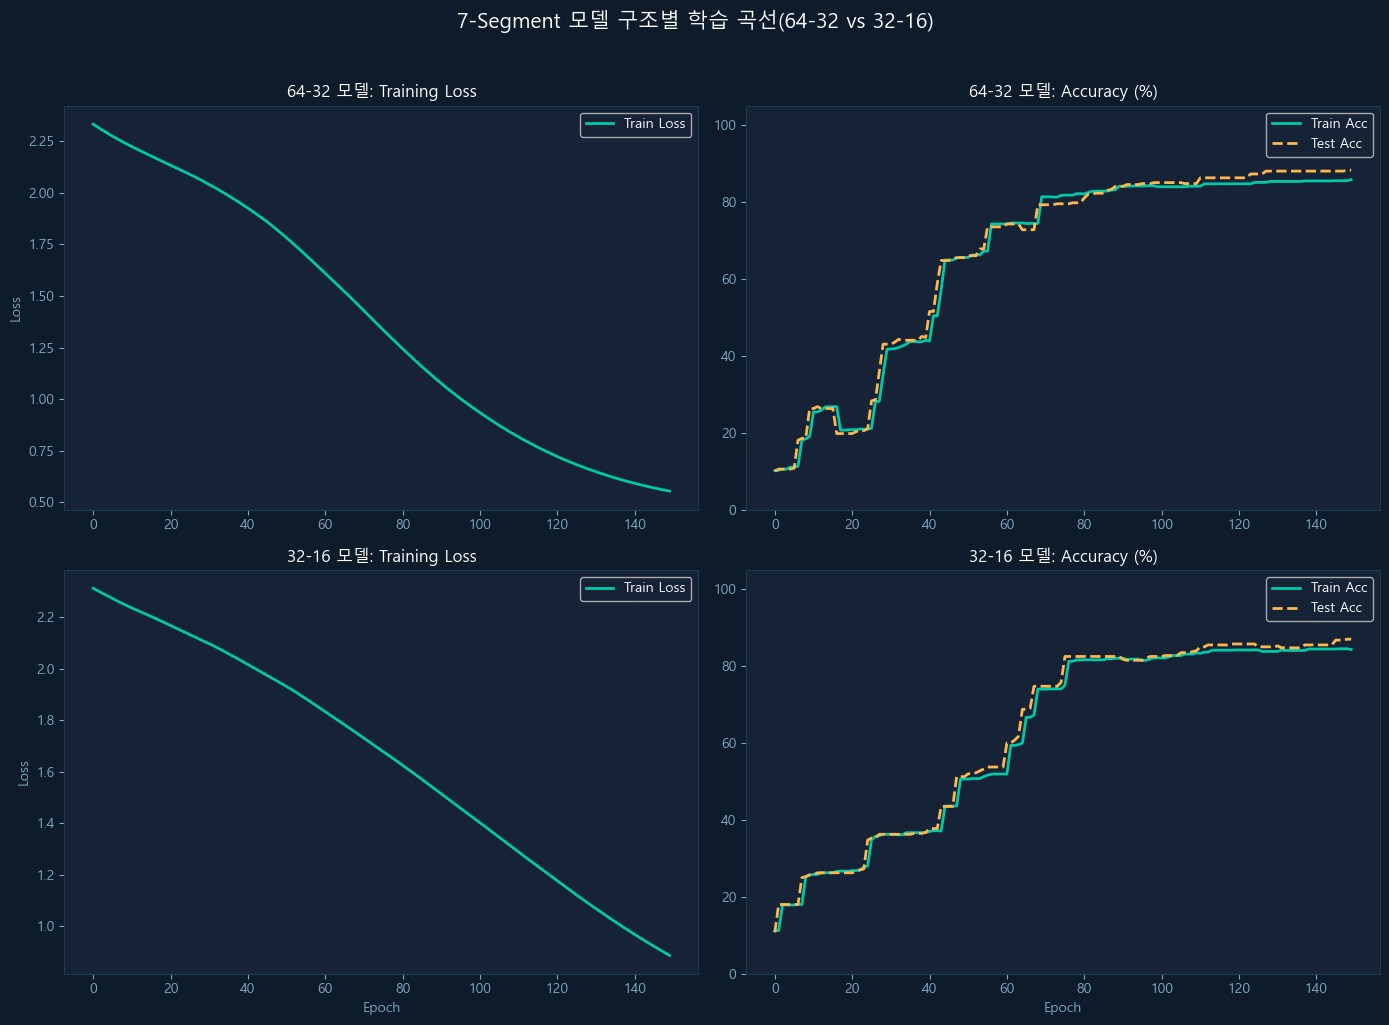


[최종 결과 요약]
1️. Hidden Layer(64-32): 88.25%
2️. Hidden Layer(32-16): 87.00%


In [43]:
# 1. 기초 : 노이즈 확률을 0.1, 0.2로 높여 정확도 확인 및 히든 레이어 크기를 64 -> 32 로 변환
# 1-2 히든레이어를 64 -> 32로 변환하기
# 데이터 증강
def augment_data(segments_dict, samples_per_class, noise_prob):
    """
    각 숫자 패턴에 랜덤 노이즈(비트 플립)를 추가하여 학습 데이터를 생성합니다.
    
    Args:
        samples_per_class: 각 클래스당 생성할 샘플 수
        noise_prob: 각 비트가 뒤집힐 확률
    """
    X_list, y_list = [], []
    for digit, pattern in segments_dict.items():
        for _ in range(samples_per_class):
            # 노이즈 생성: 각 비트를 noise_prob 확률로 플립
            noise = np.random.binomial(1, noise_prob, size=7) #binomial : 이항분포
            noisy = np.array(pattern) ^ noise  # XOR로 비트 플립
            X_list.append(noisy.astype(np.float32))
            y_list.append(digit)

    return np.array(X_list), np.array(y_list)

# 데이터 만들기(노이즈 확률 0.05 고정)
X, y = augment_data(SEGMENTS, samples_per_class=200, noise_prob=0.05)

# Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify=y : 각 digit 데이터들이 같은 비율로 훈련셋과 테스트셋에 담기도록 함
)

# PyTorch 텐서로 변환
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)


# MLP 모델 정의
class SevenSegmentNet(nn.Module):
    """
    7-Segment 숫자 분류를 위한 MLP 모델
    
    Architecture:
        기본 설정 Input(7) → FC(32) → ReLU → FC(16) → ReLU → FC(10)
    """
    def __init__(self, input_size=7, hidden1=32, hidden2=16, num_classes=10):
        super(SevenSegmentNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),  # 입력층 → 은닉층 1
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),     # 은닉층 1 → 은닉층 2
            nn.ReLU(),
            nn.Linear(hidden2, num_classes), # 은닉층 2 → 출력층
        )
        # 가중치 초기화 (Xavier Uniform)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """순전파: CrossEntropyLoss가 내부적으로 Softmax를 포함하므로 raw logits 반환"""
        return self.network(x)


# 모델 생성 및 구조 출력
model = SevenSegmentNet().to(device)
print('\n모델정보 : ', model)
print(f'\n총 파라미터 수: {sum(p.numel() for p in model_info.parameters()):,}개')


# ─── 하이퍼파라미터 ───────────────────────────────────────────────────────
LEARNING_RATE = 0.001
NUM_EPOCHS    = 150

# 손실함수 
criterion = nn.CrossEntropyLoss()  # 다중 클래스 분류 손실함수 (Softmax 포함)

# 학습기록
histories = []

# ─── 학습 루프 ────────────────────────────────────────────────────────────
# 64-32 구조와 32-16 구조 비교 설정
configs = [
    {'h1': 64, 'h2': 32, 'name': 'Hidden Layer(64-32)'},
    {'h1': 32, 'h2': 16, 'name': 'Hidden Layer(32-16)'}
]

for config in configs:
    print(f"\n🚀 {config['name']} 모델 학습 시작...")
    
    # 모델 초기화 (입력받은 h1, h2 크기로 생성)
    model = SevenSegmentNet(hidden1=config['h1'], hidden2=config['h2']).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    history = {'train_acc': [], 'test_acc': [], 'train_loss': []}


    for epoch in range(NUM_EPOCHS):
    # ── 학습 모드 ──
        model.train()
        optimizer.zero_grad()          # 이전 그래디언트 초기화
        outputs = model(X_train_t)     # 순전파
        loss = criterion(outputs, y_train_t)  # 손실 계산
        loss.backward()                # 역전파
        optimizer.step()               # 가중치 업데이트

    # ── 학습 정확도 ──
        _, predicted_train = torch.max(outputs, 1)
        train_acc = (predicted_train == y_train_t).float().mean().item()

    # ── 테스트 평가 및 정확도 ──
        model.eval()
        with torch.no_grad():   ## 이미 미분을 했기에 평가할 때는 no_grad로!! 매우 중요-대형 모델 성능영향
            test_outputs  = model(X_test_t)
            _, predicted_test = torch.max(test_outputs, 1)
            test_acc = (predicted_test == y_test_t).float().mean().item()

    # 기록 저장 // matplotlib 같은 시각화 도구를 써서 오차 그래프, 정확도 그래프를 그릴 재료 모으기
        history['train_loss'].append(loss.item())
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

    # 진행 상황 출력 (매 30 epoch)
        if (epoch + 1) % 30 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1:>3}/{NUM_EPOCHS}]  '  # :>3 출력시 앞 쪽에 3칸의 여백을 써주기
                  f'Loss: {loss.item():.4f}  '
                  f'Train Acc: {train_acc*100:.1f}%  '
                  f'Test Acc: {test_acc*100:.1f}%')
    histories.append(history)

    print(f"\n✅ {config['name']} 모델 학습 완료!")

    # 모델 저장
    torch.save(model.state_dict(), f"model_{config['h1']}_{config['h2']}.pth")
    print(f"모델저장완료 : model_{config['h1']}_{config['h2']}.pth")

# ─── 학습 곡선 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) # 2행 2열 구조
fig.patch.set_facecolor('#0d1b2a')
for ax in axes.flatten():
    ax.set_facecolor('#162236')
    ax.tick_params(colors='#7fa8c4')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e3a54')
    ax.grid(alpha=0.2, color='#1e3a54')

# 64-32 모델 손실 곡선
ax1 = axes[0, 0]
ax1.plot(histories[0]['train_loss'], color='#00c9a7', linewidth=2, label='Train Loss')
ax1.set_title('64-32 모델: Training Loss', color='white', fontsize=12)
ax1.set_ylabel('Loss', color='#7fa8c4')
ax1.legend(facecolor='#162236', labelcolor='white')

# 64-32 모델 정확도 곡선
ax2 = axes[0, 1]
ax2.plot([a*100 for a in histories[0]['train_acc']], color='#00c9a7', linewidth=2, label='Train Acc')
ax2.plot([a*100 for a in histories[0]['test_acc']],  color='#ffb74d', linewidth=2, label='Test Acc', linestyle='--')
ax2.set_title('64-32 모델: Accuracy (%)', color='white', fontsize=12)
ax2.set_ylim(0, 105)
ax2.legend(facecolor='#162236', labelcolor='white')

# 32-16 모델 손실 곡선
ax3 = axes[1, 0]
ax3.plot(histories[1]['train_loss'], color='#00c9a7', linewidth=2, label='Train Loss')
ax3.set_title('32-16 모델: Training Loss', color='white', fontsize=12)
ax3.set_ylabel('Loss', color='#7fa8c4')
ax3.set_xlabel('Epoch', color='#7fa8c4')
ax3.legend(facecolor='#162236', labelcolor='white')

# 32-16 모델 정확도 곡선
ax4 = axes[1, 1]
ax4.plot([a*100 for a in histories[1]['train_acc']], color='#00c9a7', linewidth=2, label='Train Acc')
ax4.plot([a*100 for a in histories[1]['test_acc']],  color='#ffb74d', linewidth=2, label='Test Acc', linestyle='--')
ax4.set_title('32-16 모델: Accuracy (%)', color='white', fontsize=12)
ax4.set_xlabel('Epoch', color='#7fa8c4')
ax4.set_ylim(0, 105)
ax4.legend(facecolor='#162236', labelcolor='white')

plt.suptitle('7-Segment 모델 구조별 학습 곡선(64-32 vs 32-16)', color='white', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# 최종 결과 요약
print(f"\n[최종 결과 요약]")
print(f"1️. {configs[0]['name']}: {histories[0]['test_acc'][-1]*100:.2f}%")
print(f"2️. {configs[1]['name']}: {histories[1]['test_acc'][-1]*100:.2f}%")


모델정보 :  SevenSegmentNet(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=10, bias=True)
  )
)

총 파라미터 수: 954개

🚀 Optimizer: Adam 모델 학습 시작...
Epoch [  1/150]  Loss: 2.4417  Train Acc: 9.9%  Test Acc: 10.2%
Epoch [ 30/150]  Loss: 2.1845  Train Acc: 11.7%  Test Acc: 9.7%
Epoch [ 60/150]  Loss: 1.9793  Train Acc: 44.6%  Test Acc: 43.3%
Epoch [ 90/150]  Loss: 1.7149  Train Acc: 53.9%  Test Acc: 52.2%
Epoch [120/150]  Loss: 1.4041  Train Acc: 67.9%  Test Acc: 66.0%
Epoch [150/150]  Loss: 1.0819  Train Acc: 83.2%  Test Acc: 81.0%

✅ Optimizer: Adam 모델 학습 완료!
모델저장완료 : model_32_16_Adam.pth

🚀 Optimizer: SGD (momentum=0.9) 모델 학습 시작...
Epoch [  1/150]  Loss: 2.3356  Train Acc: 3.4%  Test Acc: 2.7%
Epoch [ 30/150]  Loss: 2.3046  Train Acc: 11.2%  Test Acc: 11.0%
Epoch [ 60/150]  Loss: 2.2718  Train Acc: 11.5%  Test Acc: 11.2%


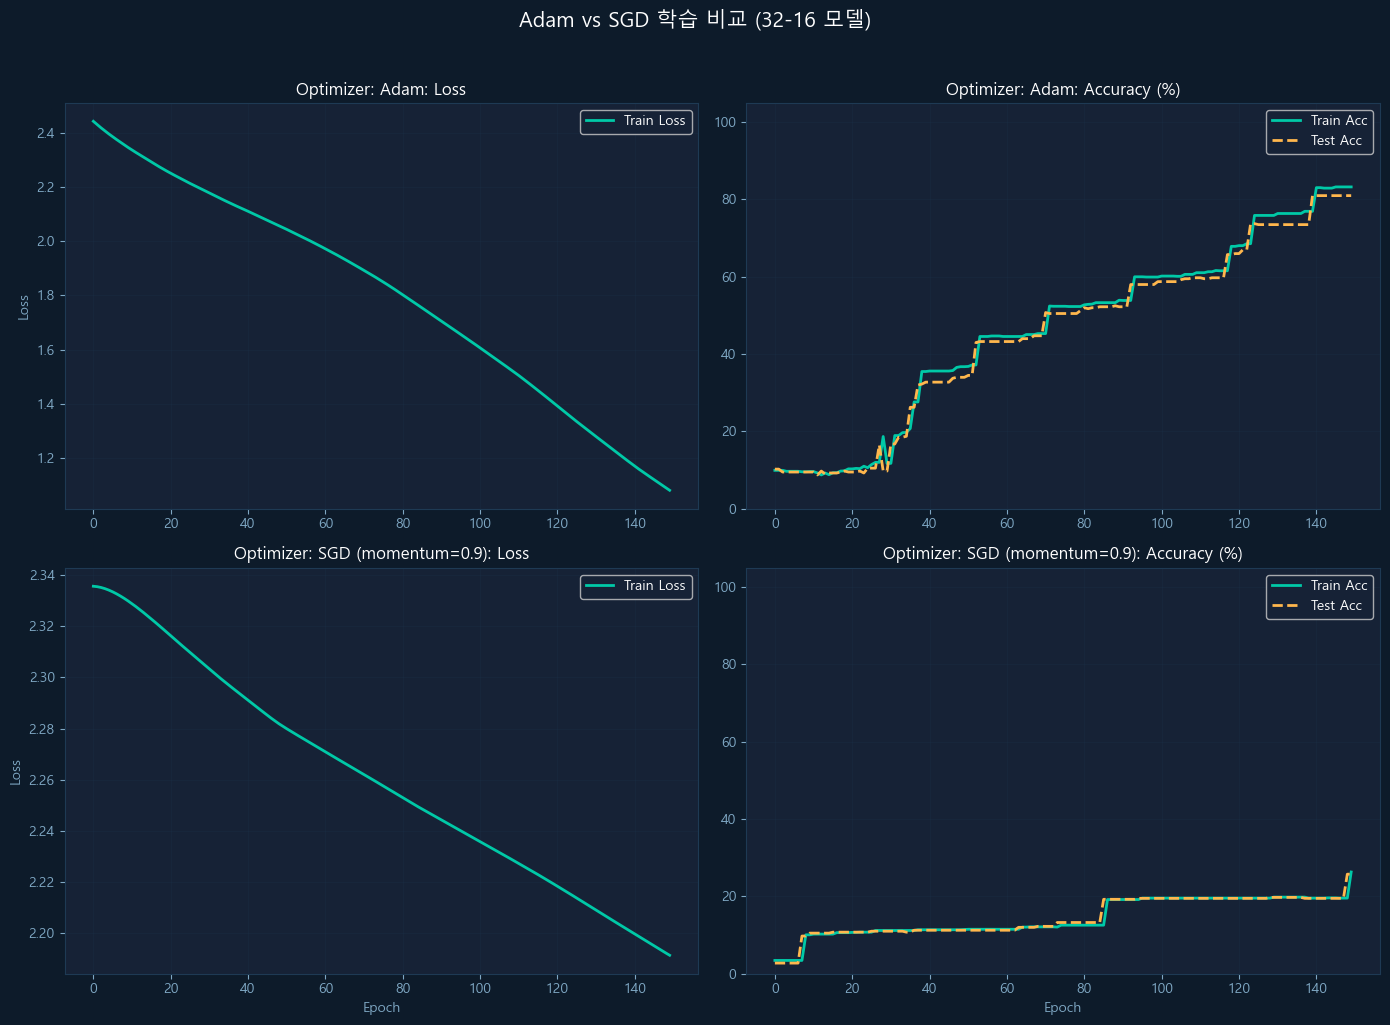


[최종 결과 요약]
1️. Optimizer: Adam: 81.00%
2️. Optimizer: SGD (momentum=0.9): 25.75%


In [42]:
# 2. 중급 : Adam 대신 SGD(momentum=0.9), 학습률을 0.01, 0.0001로 바꿔 수렴 속도 비교
# 2-1 Adam 대신 SGD(momentum=0.9)를 사용해보기 
# 데이터 증강
def augment_data(segments_dict, samples_per_class, noise_prob):
    """
    각 숫자 패턴에 랜덤 노이즈(비트 플립)를 추가하여 학습 데이터를 생성합니다.
    
    Args:
        samples_per_class: 각 클래스당 생성할 샘플 수
        noise_prob: 각 비트가 뒤집힐 확률
    """
    X_list, y_list = [], []
    for digit, pattern in segments_dict.items():
        for _ in range(samples_per_class):
            # 노이즈 생성: 각 비트를 noise_prob 확률로 플립
            noise = np.random.binomial(1, noise_prob, size=7) #binomial : 이항분포
            noisy = np.array(pattern) ^ noise  # XOR로 비트 플립
            X_list.append(noisy.astype(np.float32))
            y_list.append(digit)

    return np.array(X_list), np.array(y_list)

# 데이터 만들기(노이즈 확률 0.05 고정)
X, y = augment_data(SEGMENTS, samples_per_class=200, noise_prob=0.05)

# Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify=y : 각 digit 데이터들이 같은 비율로 훈련셋과 테스트셋에 담기도록 함
)

# PyTorch 텐서로 변환
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)


# MLP 모델 정의
class SevenSegmentNet(nn.Module):
    """
    7-Segment 숫자 분류를 위한 MLP 모델
    
    Architecture:
        기본 설정 Input(7) → FC(32) → ReLU → FC(16) → ReLU → FC(10)
    """
    def __init__(self, input_size=7, hidden1=32, hidden2=16, num_classes=10):
        super(SevenSegmentNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),  # 입력층 → 은닉층 1
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),     # 은닉층 1 → 은닉층 2
            nn.ReLU(),
            nn.Linear(hidden2, num_classes), # 은닉층 2 → 출력층
        )
        # 가중치 초기화 (Xavier Uniform)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """순전파: CrossEntropyLoss가 내부적으로 Softmax를 포함하므로 raw logits 반환"""
        return self.network(x)


# 모델 생성 및 구조 출력
model = SevenSegmentNet().to(device)
print('\n모델정보 : ', model)
print(f'\n총 파라미터 수: {sum(p.numel() for p in model_info.parameters()):,}개')


# ─── 하이퍼파라미터 ───────────────────────────────────────────────────────
LEARNING_RATE = 0.001
NUM_EPOCHS    = 150

# 손실함수 
criterion = nn.CrossEntropyLoss()  # 다중 클래스 분류 손실함수 (Softmax 포함)

# 학습기록
histories = []

# ─── 학습 루프 ────────────────────────────────────────────────────────────
# 64-32 구조와 32-16 구조 비교 설정
configs = [
    {'opt': 'Adam', 'name': 'Optimizer: Adam'},
    {'opt': 'SGD',  'name': 'Optimizer: SGD (momentum=0.9)'}
]

for config in configs:
    print(f"\n🚀 {config['name']} 모델 학습 시작...")
    
    # 모델 초기화 
    model = SevenSegmentNet().to(device)
    if config['opt'] == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    else:
        optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)
    
    history = {'train_acc': [], 'test_acc': [], 'train_loss': []}


    for epoch in range(NUM_EPOCHS):
    # ── 학습 모드 ──
        model.train()
        optimizer.zero_grad()          # 이전 그래디언트 초기화
        outputs = model(X_train_t)     # 순전파
        loss = criterion(outputs, y_train_t)  # 손실 계산
        loss.backward()                # 역전파
        optimizer.step()               # 가중치 업데이트

    # ── 학습 정확도 ──
        _, predicted_train = torch.max(outputs, 1)
        train_acc = (predicted_train == y_train_t).float().mean().item()

    # ── 테스트 평가 및 정확도 ──
        model.eval()
        with torch.no_grad():   ## 이미 미분을 했기에 평가할 때는 no_grad로!! 매우 중요-대형 모델 성능영향
            test_outputs  = model(X_test_t)
            _, predicted_test = torch.max(test_outputs, 1)
            test_acc = (predicted_test == y_test_t).float().mean().item()

    # 기록 저장 // matplotlib 같은 시각화 도구를 써서 오차 그래프, 정확도 그래프를 그릴 재료 모으기
        history['train_loss'].append(loss.item())
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

    # 진행 상황 출력 (매 30 epoch)
        if (epoch + 1) % 30 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1:>3}/{NUM_EPOCHS}]  '  # :>3 출력시 앞 쪽에 3칸의 여백을 써주기
                  f'Loss: {loss.item():.4f}  '
                  f'Train Acc: {train_acc*100:.1f}%  '
                  f'Test Acc: {test_acc*100:.1f}%')
    histories.append(history)

    print(f"\n✅ {config['name']} 모델 학습 완료!")

    # 모델 저장
    torch.save(model.state_dict(), f"model_32_16_{config['opt']}.pth")
    print(f"모델저장완료 : model_32_16_{config['opt']}.pth")

# ─── 학습 곡선 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) # 2행 2열 구조
fig.patch.set_facecolor('#0d1b2a')
for ax in axes.flatten():
    ax.set_facecolor('#162236')
    ax.tick_params(colors='#7fa8c4')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e3a54')
    ax.grid(alpha=0.2, color='#1e3a54')

# 32-16 모델(Adam) 손실 곡선
ax1 = axes[0, 0]
ax1.plot(histories[0]['train_loss'], color='#00c9a7', linewidth=2, label='Train Loss')
ax1.set_title(f"{configs[0]['name']}: Loss", color='white', fontsize=12)
ax1.set_ylabel('Loss', color='#7fa8c4')
ax1.legend(facecolor='#162236', labelcolor='white')

# 32-16 모델(Adam) 정확도 곡선
ax2 = axes[0, 1]
ax2.plot([a*100 for a in histories[0]['train_acc']], color='#00c9a7', linewidth=2, label='Train Acc')
ax2.plot([a*100 for a in histories[0]['test_acc']],  color='#ffb74d', linewidth=2, label='Test Acc', linestyle='--')
ax2.set_title(f"{configs[0]['name']}: Accuracy (%)", color='white', fontsize=12)
ax2.set_ylim(0, 105)
ax2.legend(facecolor='#162236', labelcolor='white')

# 32-16 모델(SGD) 손실 곡선
ax3 = axes[1, 0]
ax3.plot(histories[1]['train_loss'], color='#00c9a7', linewidth=2, label='Train Loss')
ax3.set_title(f"{configs[1]['name']}: Loss", color='white', fontsize=12)
ax3.set_ylabel('Loss', color='#7fa8c4')
ax3.set_xlabel('Epoch', color='#7fa8c4')
ax3.legend(facecolor='#162236', labelcolor='white')

# 32-16 모델(SGD) 정확도 곡선
ax4 = axes[1, 1]
ax4.plot([a*100 for a in histories[1]['train_acc']], color='#00c9a7', linewidth=2, label='Train Acc')
ax4.plot([a*100 for a in histories[1]['test_acc']],  color='#ffb74d', linewidth=2, label='Test Acc', linestyle='--')
ax4.set_title(f"{configs[1]['name']}: Accuracy (%)", color='white', fontsize=12)
ax4.set_xlabel('Epoch', color='#7fa8c4')
ax4.set_ylim(0, 105)
ax4.legend(facecolor='#162236', labelcolor='white')

plt.suptitle('Adam vs SGD 학습 비교 (32-16 모델)', color='white', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# 최종 결과 요약
print(f"\n[최종 결과 요약]")
print(f"1️. {configs[0]['name']}: {histories[0]['test_acc'][-1]*100:.2f}%")
print(f"2️. {configs[1]['name']}: {histories[1]['test_acc'][-1]*100:.2f}%")




모델정보 :  SevenSegmentNet(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=10, bias=True)
  )
)

총 파라미터 수: 954개

🚀 LR: 0.01 (High) 모델 학습 시작...
Epoch [  1/150]  Loss: 2.3476  Train Acc: 10.4%  Test Acc: 10.0%
Epoch [ 30/150]  Loss: 0.7435  Train Acc: 85.2%  Test Acc: 83.2%
Epoch [ 60/150]  Loss: 0.4214  Train Acc: 87.6%  Test Acc: 84.0%
Epoch [ 90/150]  Loss: 0.3934  Train Acc: 87.9%  Test Acc: 83.7%
Epoch [120/150]  Loss: 0.3870  Train Acc: 88.1%  Test Acc: 83.7%
Epoch [150/150]  Loss: 0.3837  Train Acc: 88.0%  Test Acc: 83.7%

✅ LR: 0.01 (High) 모델 학습 완료!

🚀 LR: 0.001 (Default) 모델 학습 시작...
Epoch [  1/150]  Loss: 2.3082  Train Acc: 18.3%  Test Acc: 19.5%
Epoch [ 30/150]  Loss: 2.1233  Train Acc: 27.9%  Test Acc: 28.0%
Epoch [ 60/150]  Loss: 1.9194  Train Acc: 58.8%  Test Acc: 58.0%
Epoch [ 90/150]  Loss: 1.6581  Train

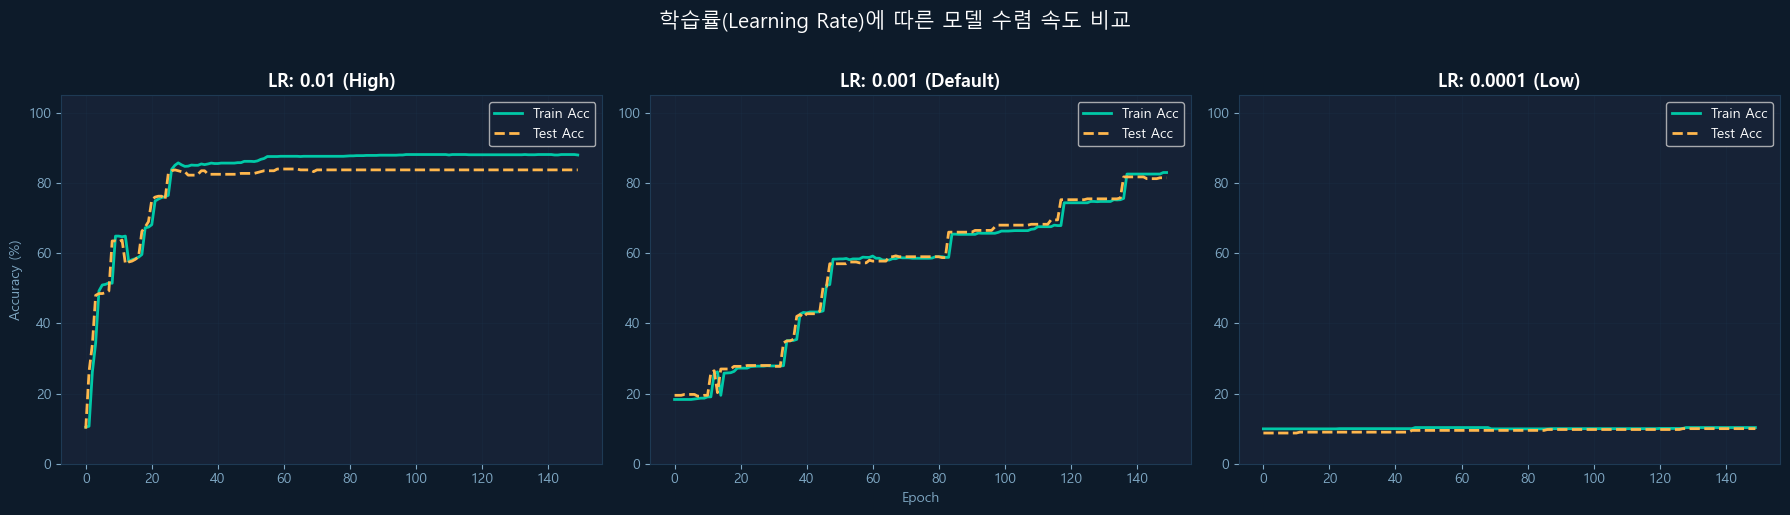


최종 결과 및 수렴 속도 요약
1️. LR: 0.01 (High)    | 최종 정확도: 83.75% | 80% 도달 시점: 26 Epoch
2️. LR: 0.001 (Default) | 최종 정확도: 81.50% | 80% 도달 시점: 137 Epoch
3️. LR: 0.0001 (Low)   | 최종 정확도: 10.00% | 80% 도달 시점: 미도달 Epoch


In [41]:
# 2. 중급 : Adam 대신 SGD(momentum=0.9), 학습률을 0.01, 0.0001로 바꿔 수렴 속도 비교
# 2-2  학습률을 0.01, 0.0001로 바꿔 수렴 속도 비교
# 데이터 증강
def augment_data(segments_dict, samples_per_class, noise_prob):
    """
    각 숫자 패턴에 랜덤 노이즈(비트 플립)를 추가하여 학습 데이터를 생성합니다.
    
    Args:
        samples_per_class: 각 클래스당 생성할 샘플 수
        noise_prob: 각 비트가 뒤집힐 확률
    """
    X_list, y_list = [], []
    for digit, pattern in segments_dict.items():
        for _ in range(samples_per_class):
            # 노이즈 생성: 각 비트를 noise_prob 확률로 플립
            noise = np.random.binomial(1, noise_prob, size=7) #binomial : 이항분포
            noisy = np.array(pattern) ^ noise  # XOR로 비트 플립
            X_list.append(noisy.astype(np.float32))
            y_list.append(digit)

    return np.array(X_list), np.array(y_list)

# 데이터 만들기(노이즈 확률 0.05 고정)
X, y = augment_data(SEGMENTS, samples_per_class=200, noise_prob=0.05)

# Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify=y : 각 digit 데이터들이 같은 비율로 훈련셋과 테스트셋에 담기도록 함
)

# PyTorch 텐서로 변환
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)


# MLP 모델 정의
class SevenSegmentNet(nn.Module):
    """
    7-Segment 숫자 분류를 위한 MLP 모델
    
    Architecture:
        기본 설정 Input(7) → FC(32) → ReLU → FC(16) → ReLU → FC(10)
    """
    def __init__(self, input_size=7, hidden1=32, hidden2=16, num_classes=10):
        super(SevenSegmentNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),  # 입력층 → 은닉층 1
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),     # 은닉층 1 → 은닉층 2
            nn.ReLU(),
            nn.Linear(hidden2, num_classes), # 은닉층 2 → 출력층
        )
        # 가중치 초기화 (Xavier Uniform)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """순전파: CrossEntropyLoss가 내부적으로 Softmax를 포함하므로 raw logits 반환"""
        return self.network(x)


# 모델 생성 및 구조 출력
model = SevenSegmentNet().to(device)
print('\n모델정보 : ', model)
print(f'\n총 파라미터 수: {sum(p.numel() for p in model_info.parameters()):,}개')


# ─── 하이퍼파라미터 ───────────────────────────────────────────────────────
NUM_EPOCHS = 150

# 손실함수
criterion = nn.CrossEntropyLoss()  # 다중 클래스 분류 손실함수 (Softmax 포함)

# 학습기록
histories = []

# ─── 학습 루프 ────────────────────────────────────────────────────────────
# 학습률 비교 구조 설정
configs = [
    {'lr': 0.01,   'name': 'LR: 0.01 (High)'},
    {'lr': 0.001,  'name': 'LR: 0.001 (Default)'},
    {'lr': 0.0001, 'name': 'LR: 0.0001 (Low)'}
]

for config in configs:
    print(f"\n🚀 {config['name']} 모델 학습 시작...")
    
    # 모델 초기화 
    model = SevenSegmentNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])

    history = {'train_acc': [], 'test_acc': [], 'train_loss': []}

    for epoch in range(NUM_EPOCHS):
    # ── 학습 모드 ──
        model.train()
        optimizer.zero_grad()          # 이전 그래디언트 초기화
        outputs = model(X_train_t)     # 순전파
        loss = criterion(outputs, y_train_t)  # 손실 계산
        loss.backward()                # 역전파
        optimizer.step()               # 가중치 업데이트

    # ── 학습 정확도 ──
        _, predicted_train = torch.max(outputs, 1)
        train_acc = (predicted_train == y_train_t).float().mean().item()

    # ── 테스트 평가 및 정확도 ──
        model.eval()
        with torch.no_grad():   ## 이미 미분을 했기에 평가할 때는 no_grad로!! 매우 중요-대형 모델 성능영향
            test_outputs  = model(X_test_t)
            _, predicted_test = torch.max(test_outputs, 1)
            test_acc = (predicted_test == y_test_t).float().mean().item()

    # 기록 저장 // matplotlib 같은 시각화 도구를 써서 오차 그래프, 정확도 그래프를 그릴 재료 모으기
        history['train_loss'].append(loss.item())
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

    # 진행 상황 출력 (매 30 epoch)
        if (epoch + 1) % 30 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1:>3}/{NUM_EPOCHS}]  '  # :>3 출력시 앞 쪽에 3칸의 여백을 써주기
                  f'Loss: {loss.item():.4f}  '
                  f'Train Acc: {train_acc*100:.1f}%  '
                  f'Test Acc: {test_acc*100:.1f}%')
    histories.append(history)

    print(f"\n✅ {config['name']} 모델 학습 완료!")


# ─── 수렴속도 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # 1행 3열 구조
fig.patch.set_facecolor('#0d1b2a')
for ax in axes.flatten():
    ax.set_facecolor('#162236')
    ax.tick_params(colors='#7fa8c4')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e3a54')
    ax.grid(alpha=0.2, color='#1e3a54')

# 학습률: 0.01 (High) 모델 곡선
ax1 = axes[0]
ax1.plot([a*100 for a in histories[0]['train_acc']], color='#00c9a7', linewidth=2, label='Train Acc')
ax1.plot([a*100 for a in histories[0]['test_acc']],  color='#ffb74d', linewidth=2, linestyle='--', label='Test Acc')
ax1.set_title('LR: 0.01 (High)', color='white', fontsize=13, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', color='#7fa8c4')
ax1.set_ylim(0, 105)
ax1.legend(facecolor='#162236', labelcolor='white')

# 학습률: 0.001 (Default) 모델 곡선
ax2 = axes[1]
ax2.plot([a*100 for a in histories[1]['train_acc']], color='#00c9a7', linewidth=2, label='Train Acc')
ax2.plot([a*100 for a in histories[1]['test_acc']],  color='#ffb74d', linewidth=2, linestyle='--', label='Test Acc')
ax2.set_title('LR: 0.001 (Default)', color='white', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch', color='#7fa8c4')
ax2.set_ylim(0, 105)
ax2.legend(facecolor='#162236', labelcolor='white')

# 학습률: 0.0001 (Low) 모델 곡선
ax3 = axes[2]
ax3.plot([a*100 for a in histories[2]['train_acc']], color='#00c9a7', linewidth=2, label='Train Acc')
ax3.plot([a*100 for a in histories[2]['test_acc']],  color='#ffb74d', linewidth=2, linestyle='--', label='Test Acc')
ax3.set_title('LR: 0.0001 (Low)', color='white', fontsize=13, fontweight='bold')
ax3.set_ylim(0, 105)
ax3.legend(facecolor='#162236', labelcolor='white')

plt.suptitle('학습률(Learning Rate)에 따른 모델 수렴 속도 비교', color='white', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# 최종 결과 요약
print(f"\n최종 결과 및 수렴 속도 요약")
for i, config in enumerate(configs):
    final_acc = histories[i]['test_acc'][-1] * 100
    
    # 80% 정확도에 도달한 첫 번째 에폭 찾기 (수렴 속도 지표)
    # 리스트에서 0.80보다 큰 첫 번째 인덱스를 찾아 에폭 번호로 변환
    target_acc = 0.80
    epochs_to_target = next((idx + 1 for idx, acc in enumerate(histories[i]['test_acc']) if acc >= target_acc), "미도달")
    
    print(f"{i+1}️. {config['name']:<18} | 최종 정확도: {final_acc:.2f}% | 80% 도달 시점: {epochs_to_target} Epoch")




모델정보 :  SevenSegmentNet(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=10, bias=True)
  )
)

총 파라미터 수: 954개

🚀 기본 모델 (No Dropout) 모델 학습 시작...
Epoch [  1/600]  Loss: 2.4479  Train Acc: 10.1%  Test Acc: 10.5%
Epoch [ 30/600]  Loss: 2.2709  Train Acc: 3.1%  Test Acc: 3.7%
Epoch [ 60/600]  Loss: 2.1626  Train Acc: 27.7%  Test Acc: 27.3%
Epoch [ 90/600]  Loss: 1.9822  Train Acc: 35.7%  Test Acc: 34.5%
Epoch [120/600]  Loss: 1.6751  Train Acc: 59.6%  Test Acc: 58.2%
Epoch [150/600]  Loss: 1.3295  Train Acc: 68.1%  Test Acc: 68.3%
Epoch [180/600]  Loss: 0.9976  Train Acc: 82.8%  Test Acc: 82.7%
Epoch [210/600]  Loss: 0.7574  Train Acc: 85.2%  Test Acc: 85.7%
Epoch [240/600]  Loss: 0.6108  Train Acc: 85.7%  Test Acc: 85.7%
Epoch [270/600]  Loss: 0.5319  Train Acc: 86.4%  Test Acc: 87.3%
Epoch [300/600]  Loss: 0.4897  Tra

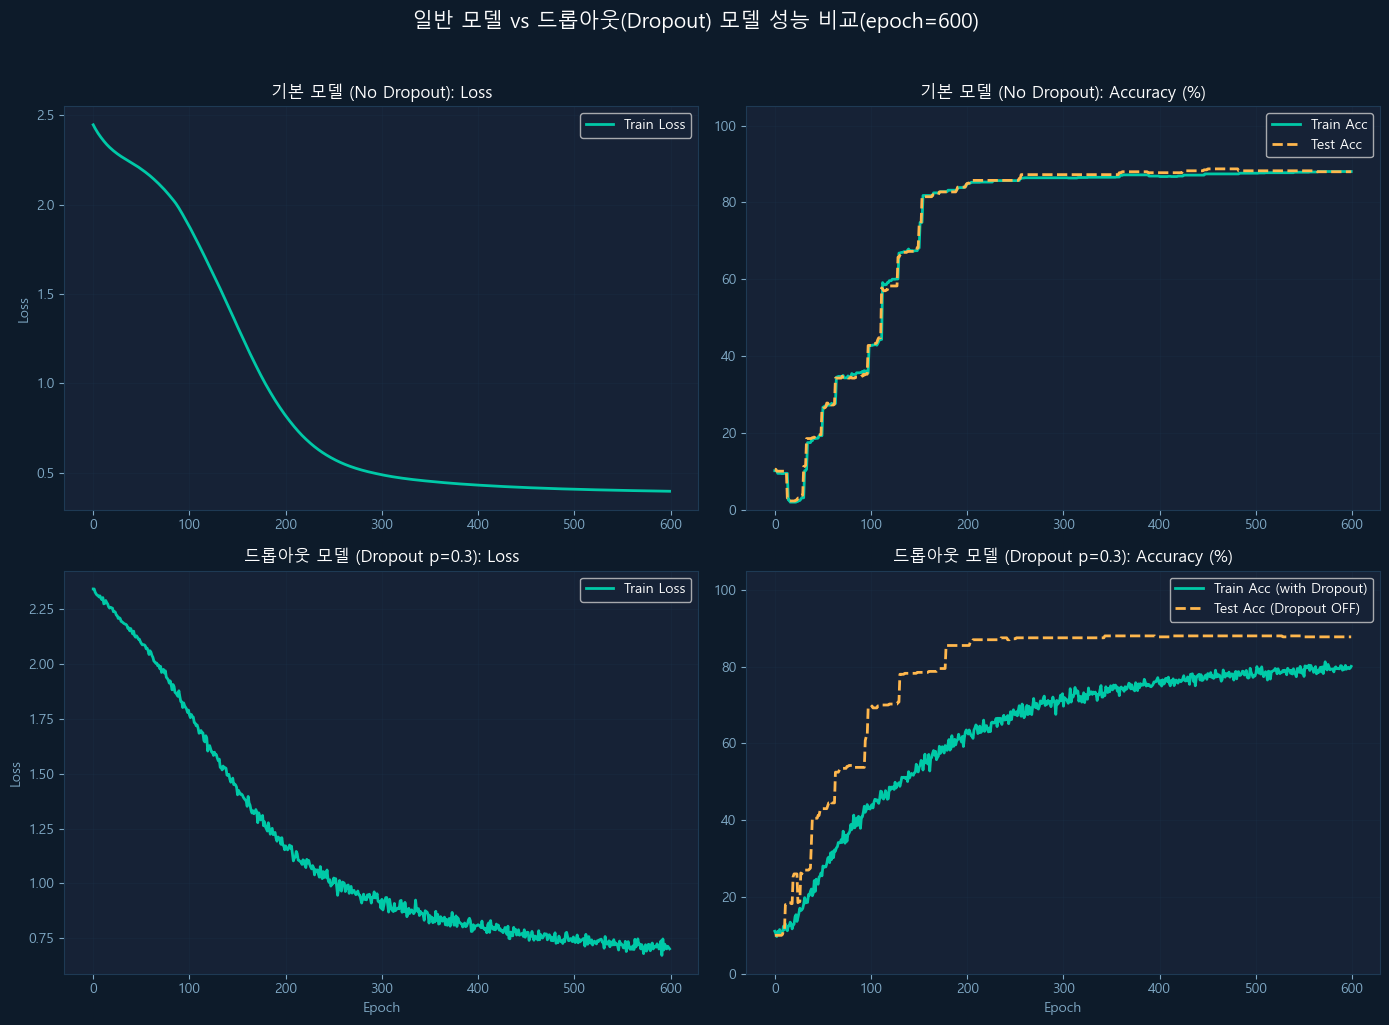


최종 성능 비교 결과(epoch=600)
1. 기본 모델 (No Dropout)        : 88.00%
2. 드롭아웃 모델 (Dropout p=0.3)   : 87.75%


In [38]:
# 3. 심화 : nn.Dropout(0.3)을 은닉층 사이에 추가, 새로운 숫자(예: 0~9 외의 특수 패턴)을 직접 정의하여 클래스에 추가하기
# 3-1  nn.Dropout(0.3)을 은닉층 사이에 추가하여 효과 확인
# 데이터 증강
def augment_data(segments_dict, samples_per_class, noise_prob):
    """
    각 숫자 패턴에 랜덤 노이즈(비트 플립)를 추가하여 학습 데이터를 생성합니다.
    
    Args:
        samples_per_class: 각 클래스당 생성할 샘플 수
        noise_prob: 각 비트가 뒤집힐 확률
    """
    X_list, y_list = [], []
    for digit, pattern in segments_dict.items():
        for _ in range(samples_per_class):
            # 노이즈 생성: 각 비트를 noise_prob 확률로 플립
            noise = np.random.binomial(1, noise_prob, size=7) #binomial : 이항분포
            noisy = np.array(pattern) ^ noise  # XOR로 비트 플립
            X_list.append(noisy.astype(np.float32))
            y_list.append(digit)

    return np.array(X_list), np.array(y_list)

# 데이터 만들기
X, y = augment_data(SEGMENTS, samples_per_class=200, noise_prob=0.05)

# Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify=y : 각 digit 데이터들이 같은 비율로 훈련셋과 테스트셋에 담기도록 함
)

# PyTorch 텐서로 변환
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)


# MLP 모델 정의
class SevenSegmentNet(nn.Module):
    """
    7-Segment 숫자 분류를 위한 MLP 모델
    
    Architecture:
        기본 설정 Input(7) → FC(32) → ReLU → FC(16) → ReLU → FC(10)
    """
    def __init__(self, input_size=7, hidden1=32, hidden2=16, num_classes=10, use_dropout=False):
        super(SevenSegmentNet, self).__init__()
        layers = []
        layers.append(nn.Linear(input_size, hidden1))
        layers.append(nn.ReLU())
        
        if use_dropout:
            layers.append(nn.Dropout(0.3)) # 첫 번째 은닉층 뒤에 30% 드롭아웃
            
        layers.append(nn.Linear(hidden1, hidden2))
        layers.append(nn.ReLU())
        
        if use_dropout:
            layers.append(nn.Dropout(0.3)) # 두 번째 은닉층 뒤에 30% 드롭아웃
            
        layers.append(nn.Linear(hidden2, num_classes))

        self.network = nn.Sequential(*layers)
        # 가중치 초기화 (Xavier Uniform)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """순전파: CrossEntropyLoss가 내부적으로 Softmax를 포함하므로 raw logits 반환"""
        return self.network(x)


# 모델 생성 및 구조 출력
model = SevenSegmentNet().to(device)
print('\n모델정보 : ', model)
print(f'\n총 파라미터 수: {sum(p.numel() for p in model_info.parameters()):,}개')


# ─── 하이퍼파라미터 ───────────────────────────────────────────────────────
LEARNING_RATE = 0.001
NUM_EPOCHS = 600

# 손실함수
criterion = nn.CrossEntropyLoss()  # 다중 클래스 분류 손실함수 (Softmax 포함)

# 학습기록
histories = []

# ─── 학습 루프 ────────────────────────────────────────────────────────────
# 학습률 비교 구조 설정
configs = [
    {'use_dropout': False, 'name': '기본 모델 (No Dropout)'},
    {'use_dropout': True,  'name': '드롭아웃 모델 (Dropout p=0.3)'}
]

for config in configs:
    print(f"\n🚀 {config['name']} 모델 학습 시작...")
    
    # 모델 초기화 
    model = SevenSegmentNet(use_dropout=config['use_dropout']).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {'train_acc': [], 'test_acc': [], 'train_loss': []}

    for epoch in range(NUM_EPOCHS):
    # ── 학습 모드 ──
        model.train()
        optimizer.zero_grad()          # 이전 그래디언트 초기화
        outputs = model(X_train_t)     # 순전파
        loss = criterion(outputs, y_train_t)  # 손실 계산
        loss.backward()                # 역전파
        optimizer.step()               # 가중치 업데이트

    # ── 학습 정확도 ──
        _, predicted_train = torch.max(outputs, 1)
        train_acc = (predicted_train == y_train_t).float().mean().item()

    # ── 테스트 평가 및 정확도 ──
        model.eval()
        with torch.no_grad():   ## 이미 미분을 했기에 평가할 때는 no_grad로!! 매우 중요-대형 모델 성능영향
            test_outputs  = model(X_test_t)
            _, predicted_test = torch.max(test_outputs, 1)
            test_acc = (predicted_test == y_test_t).float().mean().item()

    # 기록 저장 // matplotlib 같은 시각화 도구를 써서 오차 그래프, 정확도 그래프를 그릴 재료 모으기
        history['train_loss'].append(loss.item())
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

    # 진행 상황 출력 (매 30 epoch)
        if (epoch + 1) % 30 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1:>3}/{NUM_EPOCHS}]  '  # :>3 출력시 앞 쪽에 3칸의 여백을 써주기
                  f'Loss: {loss.item():.4f}  '
                  f'Train Acc: {train_acc*100:.1f}%  '
                  f'Test Acc: {test_acc*100:.1f}%')
    histories.append(history)

    print(f"\n✅ {config['name']} 모델 학습 완료!")

    # 모델 저장
    torch.save(model.state_dict(), f"model_32_16_{config['name']}.pth")
    print(f"모델저장완료 : model_32_16_{config['name']}.pth")

    


# 학습 곡선 시각화 
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) 
fig.patch.set_facecolor('#0d1b2a')
for ax in axes.flatten():
    ax.set_facecolor('#162236')
    ax.tick_params(colors='#7fa8c4')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e3a54')
    ax.grid(alpha=0.2, color='#1e3a54')

# 기본 모델(No Dropout) 손실 곡선
ax1 = axes[0, 0]
ax1.plot(histories[0]['train_loss'], color='#00c9a7', linewidth=2, label='Train Loss')
ax1.set_title(f"{configs[0]['name']}: Loss", color='white', fontsize=12)
ax1.set_ylabel('Loss', color='#7fa8c4')
ax1.legend(facecolor='#162236', labelcolor='white')

# 기본 모델(No Dropout) 정확도 곡선
ax2 = axes[0, 1]
ax2.plot([a*100 for a in histories[0]['train_acc']], color='#00c9a7', linewidth=2, label='Train Acc')
ax2.plot([a*100 for a in histories[0]['test_acc']],  color='#ffb74d', linewidth=2, label='Test Acc', linestyle='--')
ax2.set_title(f"{configs[0]['name']}: Accuracy (%)", color='white', fontsize=12)
ax2.set_ylim(0, 105)
ax2.legend(facecolor='#162236', labelcolor='white')

# 드롭아웃 모델(Dropout 0.3) 손실 곡선
ax3 = axes[1, 0]
ax3.plot(histories[1]['train_loss'], color='#00c9a7', linewidth=2, label='Train Loss')
ax3.set_title(f"{configs[1]['name']}: Loss", color='white', fontsize=12)
ax3.set_ylabel('Loss', color='#7fa8c4')
ax3.set_xlabel('Epoch', color='#7fa8c4')
ax3.legend(facecolor='#162236', labelcolor='white')

# 드롭아웃 모델(Dropout 0.3) 정확도 곡선
ax4 = axes[1, 1]
ax4.plot([a*100 for a in histories[1]['train_acc']], color='#00c9a7', linewidth=2, label='Train Acc (with Dropout)')
ax4.plot([a*100 for a in histories[1]['test_acc']],  color='#ffb74d', linewidth=2, label='Test Acc (Dropout OFF)', linestyle='--')
ax4.set_title(f"{configs[1]['name']}: Accuracy (%)", color='white', fontsize=12)
ax4.set_xlabel('Epoch', color='#7fa8c4')
ax4.set_ylim(0, 105)
ax4.legend(facecolor='#162236', labelcolor='white')
plt.suptitle('일반 모델 vs 드롭아웃(Dropout) 모델 성능 비교(epoch=600)', color='white', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# 최종 결과 요약
print(f"\n최종 성능 비교 결과(epoch=600)")
print(f"1. {configs[0]['name']:<25} : {histories[0]['test_acc'][-1]*100:.2f}%")
print(f"2. {configs[1]['name']:<25} : {histories[1]['test_acc'][-1]*100:.2f}%")

생성된 데이터 형태: X=(2200, 7), y=(2200,)
클래스 분포: {np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200), np.int64(4): np.int64(200), np.int64(5): np.int64(200), np.int64(6): np.int64(200), np.int64(7): np.int64(200), np.int64(8): np.int64(200), np.int64(9): np.int64(200), np.int64(10): np.int64(200)}
학습 데이터: 1760개
테스트 데이터: 440개

모델정보 :  SevenSegmentNet(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=11, bias=True)
  )
)

총 파라미터 수: 954개
특수 패턴을 포함한 모델 학습 시작 (Epochs: 150, lr: 0.001)
--------------------------------------------------
Epoch [  1/150]  Loss: 2.5374  Train Acc: 10.3%  Test Acc: 9.5%
Epoch [ 30/150]  Loss: 2.2522  Train Acc: 31.1%  Test Acc: 39.5%
Epoch [ 60/150]  Loss: 1.9878  Train Acc: 41.3%  Test Acc: 42.0%
Epoch [ 90/150]  Loss: 1.6834  Train Acc: 62.

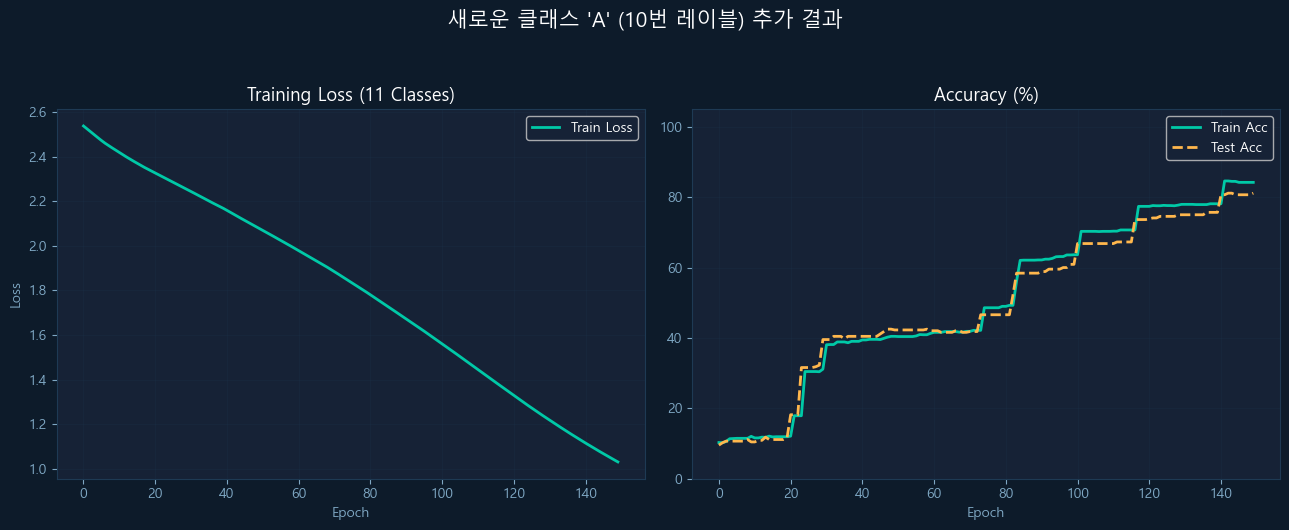


✅ 특수 패턴 포함 모델 학습 완료! (최종 Test Acc: 81.14%)


In [37]:
# 3. 심화 : nn.Dropout(0.3)을 은닉층 사이에 추가, 새로운 숫자(예: 0~9 외의 특수 패턴)을 직접 정의하여 클래스에 추가하기
# 3-2 새로운 숫자(예: 0~9 외의 특수 패턴)을 직접 정의하여 클래스에 추가하기

# ─── 7-Segment 이상적 패턴 재정의(특수패턴 추가) ───────────────────────────────────────────
#         [a, b, c, d, e, f, g]
SEGMENTS_NEW = {
    0: [1, 1, 1, 1, 1, 1, 0],
    1: [0, 1, 1, 0, 0, 0, 0],
    2: [1, 1, 0, 1, 1, 0, 1],
    3: [1, 1, 1, 1, 0, 0, 1],
    4: [0, 1, 1, 0, 0, 1, 1],
    5: [1, 0, 1, 1, 0, 1, 1],
    6: [1, 0, 1, 1, 1, 1, 1],
    7: [1, 1, 1, 0, 0, 0, 0],
    8: [1, 1, 1, 1, 1, 1, 1],
    9: [1, 1, 1, 1, 0, 1, 1],
    10: [1, 1, 1, 0, 1, 1, 1]
}

# 데이터 증강: 노이즈 추가 0.05, 01. 0.2
def augment_data(segments_dict, samples_per_class, noise_prob):
    """
    각 숫자 패턴에 랜덤 노이즈(비트 플립)를 추가하여 학습 데이터를 생성합니다.
    
    Args:
        samples_per_class: 각 클래스당 생성할 샘플 수
        noise_prob: 각 비트가 뒤집힐 확률
    """
    X_list, y_list = [], []
    for digit, pattern in segments_dict.items():
        for _ in range(samples_per_class):
            # 노이즈 생성: 각 비트를 noise_prob 확률로 플립
            noise = np.random.binomial(1, noise_prob, size=7) #binomial : 이항분포
            noisy = np.array(pattern) ^ noise  # XOR로 비트 플립
            X_list.append(noisy.astype(np.float32))
            y_list.append(digit)

    return np.array(X_list), np.array(y_list)

# 데이터 만들기
X, y = augment_data(SEGMENTS_NEW, samples_per_class=200, noise_prob=0.05)

# Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify=y : 각 digit 데이터들이 같은 비율로 훈련셋과 테스트셋에 담기도록 함
)

# PyTorch 텐서로 변환
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)

print(f'생성된 데이터 형태: X={X.shape}, y={y.shape}')
print(f'클래스 분포: {dict(zip(*np.unique(y, return_counts=True)))}')
print(f'학습 데이터: {X_train.shape[0]}개')
print(f'테스트 데이터: {X_test.shape[0]}개')


# MLP 모델 정의
class SevenSegmentNet(nn.Module):
    """
    7-Segment 숫자 분류를 위한 MLP 모델
    
    Architecture:
        Input(7) → FC(32) → ReLU → FC(16) → ReLU → FC(10)
    """
    def __init__(self, input_size=7, hidden1=32, hidden2=16, num_classes=10):
        super(SevenSegmentNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),  # 입력층 → 은닉층 1
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),     # 은닉층 1 → 은닉층 2
            nn.ReLU(),
            nn.Linear(hidden2, num_classes), # 은닉층 2 → 출력층
        )
        # 가중치 초기화 (Xavier Uniform)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """순전파: CrossEntropyLoss가 내부적으로 Softmax를 포함하므로 raw logits 반환"""
        return self.network(x)


# 모델 생성 및 구조 출력(클래스의 총개수를 넘겨주기)
model = SevenSegmentNet(num_classes=len(SEGMENTS_NEW)).to(device)
print('\n모델정보 : ', model)
print(f'\n총 파라미터 수: {sum(p.numel() for p in model_info.parameters()):,}개')


# 하이퍼파라미터 
LEARNING_RATE = 0.001
NUM_EPOCHS    = 150

# 손실함수 & 옵티마이저
criterion = nn.CrossEntropyLoss()  # 다중 클래스 분류 손실함수 (Softmax 포함)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 학습 기록 저장
history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

# 학습할 데이터 묶음 만들기

# ─── 학습 루프 ────────────────────────────────────────────────────────────
print(f'특수 패턴을 포함한 모델 학습 시작 (Epochs: {NUM_EPOCHS}, lr: {LEARNING_RATE})')
print('-' * 50)

for epoch in range(NUM_EPOCHS):
    # ── 학습 모드 ──
    model.train()
    optimizer.zero_grad()          # 이전 그래디언트 초기화
    outputs = model(X_train_t)     # 순전파
    loss = criterion(outputs, y_train_t)  # 손실 계산
    loss.backward()                # 역전파
    optimizer.step()               # 가중치 업데이트

    # ── 학습 정확도 ──
    _, predicted_train = torch.max(outputs, 1)
    train_acc = (predicted_train == y_train_t).float().mean().item()

    # ── 테스트 평가 및 정확도 ──
    model.eval()
    with torch.no_grad():   ## 이미 미분을 했기에 평가할 때는 no_grad로!! 매우 중요-대형 모델 성능영향
        test_outputs  = model(X_test_t)
        _, predicted_test = torch.max(test_outputs, 1)
        test_acc = (predicted_test == y_test_t).float().mean().item()

    # 기록 저장 // matplotlib 같은 시각화 도구를 써서 오차 그래프, 정확도 그래프를 그릴 재료 모으기
    history['train_loss'].append(loss.item())
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    # 진행 상황 출력 (매 30 epoch)
    if (epoch + 1) % 30 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:>3}/{NUM_EPOCHS}]  '  # :>3 출력시 앞 쪽에 3칸의 여백을 써주기
              f'Loss: {loss.item():.4f}  '
              f'Train Acc: {train_acc*100:.1f}%  '
              f'Test Acc: {test_acc*100:.1f}%')

print('\n✅ 특수 패턴 포함 모델 학습 완료!')

# 학습 곡선 시각화 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0d1b2a')
for ax in [ax1, ax2]:
    ax.set_facecolor('#162236')
    ax.tick_params(colors='#7fa8c4')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e3a54')
    ax.grid(alpha=0.2, color='#1e3a54')

# 손실 곡선
ax1.plot(history['train_loss'], color='#00c9a7', linewidth=2, label='Train Loss')
ax1.set_title('Training Loss (11 Classes)', color='white', fontsize=13)
ax1.set_xlabel('Epoch', color='#7fa8c4')
ax1.set_ylabel('Loss', color='#7fa8c4')
ax1.legend(facecolor='#162236', labelcolor='white')

# 정확도 곡선
ax2.plot([a*100 for a in history['train_acc']], color='#00c9a7', linewidth=2, label='Train Acc')
ax2.plot([a*100 for a in history['test_acc']],  color='#ffb74d', linewidth=2, label='Test Acc', linestyle='--')
ax2.set_title('Accuracy (%)', color='white', fontsize=13)
ax2.set_xlabel('Epoch', color='#7fa8c4')
ax2.set_ylim(0, 105)
ax2.legend(facecolor='#162236', labelcolor='white')
plt.suptitle("새로운 클래스 'A' (10번 레이블) 추가 결과", color='white', fontsize=15, y=1.05)

plt.tight_layout()
plt.show()

print(f"\n✅ 특수 패턴 포함 모델 학습 완료! (최종 Test Acc: {history['test_acc'][-1]*100:.2f}%)")